# 딥러닝 기초 II — 텐서플로우와 딥러닝 학습 방법
## Google Colab 실습용 노트북

이 노트북은 강의 자료 **2장 텐서플로우와 딥러닝 학습 방법**을 Colab에서 바로 실행할 수 있도록 구성했습니다.

**학습 목표**
- 손실 함수, 경사하강법, 순전파/역전파의 학습 원리를 수식으로 이해한다.
- TensorFlow 2.x의 Eager Execution과 텐서 기초 API를 익힌다.
- Keras로 딥러닝 모델을 구축·학습·평가·예측하는 4단계를 실습한다.
- Epoch / Batch / Iteration 관계를 코드로 확인한다.

**목차**
1. 딥러닝 모델의 학습 방법
2. 텐서플로우(TensorFlow)
3. 텐서플로우 기초 사용법
4. 텐서플로우로 딥러닝 모델 구현하기

> Colab 사용 팁: 런타임 → 런타임 유형 변경 → **GPU**를 선택하면 학습이 더 빠릅니다. (이 노트북의 예제는 CPU로도 충분합니다.)


---
## 0. Colab 환경 설정

TensorFlow 2.x는 Colab에 기본 설치되어 있습니다. 버전과 Eager Execution 여부를 먼저 확인합니다.


In [ ]:
import sys
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 운영체제가 macOS('darwin')가 아닐 경우 (예: 구글 코랩 등 리눅스 환경),
# 한글 출력을 위한 나눔 폰트를 설치하고 폰트 캐시를 초기화합니다.
if sys.platform != 'darwin':
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    !fc-cache -fv 2>/dev/null
    !rm -rf ~/.cache/matplotlib 2>/dev/null

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

In [ ]:
# =====================================================================
# 1. 시스템 경고 및 기본 데이터 분석 라이브러리 설정
# =====================================================================
import warnings
# 향후 버전 업데이트 안내 등 분석에 방해되는 불필요한 경고 메시지를 숨깁니다.
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 나눔 폰트 파일 시스템 경로를 순회하며 matplotlib 폰트 관리자에 등록합니다.
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# matplotlib 및 seaborn의 기본 설정을 변경합니다 (한글 깨짐 방지, 마이너스 부호 깨짐 방지, 고해상도 설정)
plt.rcParams.update({'font.family': 'NanumBarunGothic', 'axes.unicode_minus': False, 'figure.dpi': 110})
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})


# =====================================================================
# 2. 딥러닝 프레임워크 (TensorFlow & Keras) 불러오기
# =====================================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# =====================================================================
# 3. 난수 고정 (결과의 재현성 보장)
# =====================================================================
# 딥러닝 모델은 가중치 초기화나 데이터 셔플링 시 난수(무작위수)를 사용합니다.
# 동일한 난수 시드(Seed)를 지정하면 언제 실행해도 항상 같은 실험 결과를 얻을 수 있습니다.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)      # NumPy 수학 연산용 난수 고정
tf.random.set_seed(RANDOM_STATE)  # TensorFlow 딥러닝 연산용 난수 고정

# =====================================================================
# 4. 현재 실행 환경 검증 및 출력
# =====================================================================
print('TensorFlow version:', tf.__version__)

# Eager Execution(즉시 실행 모드): 그래프 빌드 없이 코드를 즉시 실행하는 모드 (TF 2.x 기본 활성화)
print('Eager Execution 활성화:', tf.executing_eagerly())

# 모델 가속을 위한 GPU 장치가 올바르게 할당되었는지 확인합니다.
# 리스트가 비어있다면 CPU 모드, 장치가 들어있다면 GPU 학습이 가능한 상태입니다.
print('사용 가능한 GPU:', tf.config.list_physical_devices('GPU'))
print('환경 설정 완료')

TensorFlow version: 2.20.0
Eager Execution 활성화: True
사용 가능한 GPU: []
환경 설정 완료


---
# 01. 딥러닝 모델의 학습 방법

## 1) 딥러닝 모델의 정의와 구성 요소

- **딥러닝 (Deep Learning)**: 입력층과 출력층 사이에 **은닉층(Hidden Layer)이 깊게(강의 기준 3층 이상)** 쌓인 신경망
- **레이어 (Layer)**: 모델을 구성하는 층
- **노드 / 유닛 (Node / Unit)**: 각 층을 구성하는 계산 단위
- **가중치 (Weight)**: 노드 간 연결 강도

한 층의 선형 변환은 다음과 같이 씁니다.

$$
z = W x + b
$$

활성화 함수를 거치면

$$
a = f(z)
$$

입니다. 예: Sigmoid

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$


## 2) 손실 함수(Loss Function)와 최적화(Optimization)

- **손실 함수**: 정답 $y$와 예측 $\hat{y}$의 오차
- **최적화**: 손실을 줄이도록 가중치 $W$, 편향 $b$를 찾는 과정

회귀에서 자주 쓰는 MSE:

$$
\mathrm{MSE} = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2
$$

이진 분류에서 자주 쓰는 BCE:

$$
\mathrm{BCE} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log\hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\right]
$$


## 3) 경사하강법 (Gradient Descent)

손실 함수를 최소화하기 위해, 현재 가중치에서의 **기울기(Gradient)** 반대 방향으로 갱신합니다.

$$
W_{t+1} = W_t - \alpha \nabla_W \mathrm{Loss}(W_t)
$$

$$
b_{t+1} = b_t - \alpha \nabla_b \mathrm{Loss}(b_t)
$$

- $W_t$: 현재 가중치
- $\alpha$: **학습률 (learning rate)**
- $\nabla_W \mathrm{Loss}$: 손실의 $W$에 대한 기울기

1차원 이차 함수 예시:

$$
L(w) = (w - 3)^2
$$

이면

$$
\frac{dL}{dw} = 2(w-3)
$$

이므로

$$
w_{t+1} = w_t - \alpha \cdot 2(w_t - 3)
$$

로 갱신됩니다.


=== 경사하강법 수렴 직전 기록 (마지막 5단계) ===
    step         w      loss      grad
25    25  2.988666  0.000128 -0.022667
26    26  2.990933  0.000082 -0.018134
27    27  2.992746  0.000053 -0.014507
28    28  2.994197  0.000034 -0.011606
29    29  2.995358  0.000022 -0.009285


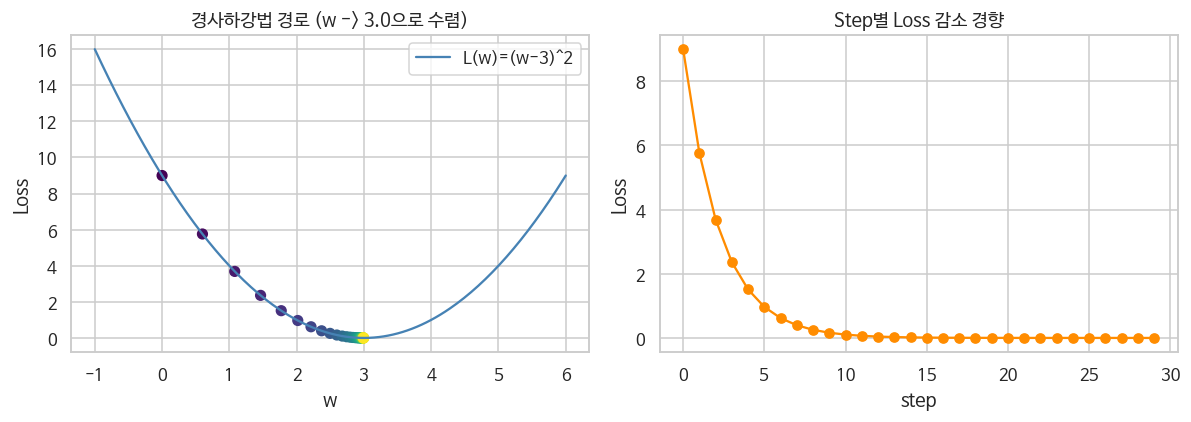

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 코드

# =====================================================================
# 4. 경사하강법 학습 경로 및 손실 감소 시각화
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# [왼쪽 그래프]: 손실 곡선 상의 경사하강법 경로 시각화
# - -1부터 6까지 200개의 구간을 촘촘히 나누어 2차 곡선 배경을 그립니다.
ws = np.linspace(-1, 6, 200)
axes[0].plot(ws, loss_fn(ws), color='steelblue', label='L(w)=(w-3)^2')

# - 가중치 w가 업데이트되는 경로를 점으로 찍어 표현합니다.
# - c=hist_df['step'], cmap='viridis': 학습 초기(어두운 보라색)부터 후기(밝은 노란색)까지 시간 흐름을 색상으로 보여줍니다.
axes[0].scatter(hist_df['w'], hist_df['loss'], c=hist_df['step'], cmap='viridis', s=40)
axes[0].set_title('경사하강법 경로 (w -> 3.0으로 수렴)')
axes[0].set_xlabel('w')
axes[0].set_ylabel('Loss')
axes[0].legend()


# [오른쪽 그래프]: 단계(Step)에 따른 손실값(Loss)의 변화 추이
# - 에포크가 진행됨에 따라 손실이 지수 함수적으로 0에 수렴해가는 과정을 보여줍니다.
axes[1].plot(hist_df['step'], hist_df['loss'], marker='o', color='darkorange')
axes[1].set_title('Step별 Loss 감소 경향')
axes[1].set_xlabel('step')
axes[1].set_ylabel('Loss')

# 여백 조절 후 최종 화면 출력
plt.tight_layout()
plt.show()

## 4) 순전파와 역전파

### 순전파 (Forward Propagation)

입력이 입력층 → 은닉층 → 출력층으로 흘러 예측값을 만듭니다.

$$
\begin{aligned}
z^{(1)} &= W^{(1)}x + b^{(1)} \\
a^{(1)} &= f(z^{(1)}) \\
z^{(2)} &= W^{(2)}a^{(1)} + b^{(2)} \\
\hat{y} &= f(z^{(2)})
\end{aligned}
$$

### 역전파 (Backpropagation)

출력층에서 입력층 방향으로 오차를 전파하며 각 가중치의 기울기를 계산합니다.  
연쇄법칙(Chain Rule):

$$
\frac{\partial L}{\partial W^{(1)}}
=
\frac{\partial L}{\partial \hat{y}}
\cdot
\frac{\partial \hat{y}}{\partial z^{(2)}}
\cdot
\frac{\partial z^{(2)}}{\partial a^{(1)}}
\cdot
\frac{\partial a^{(1)}}{\partial z^{(1)}}
\cdot
\frac{\partial z^{(1)}}{\partial W^{(1)}}
$$

즉, 어떤 가중치의 기울기를 구하려면 **그 앞단(출력 쪽)의 미분값**이 필요합니다.

### 관련 논문 / 자료

- Rumelhart, Hinton, Williams (1986): [Learning representations by back-propagating errors](https://www.nature.com/articles/323533a0)
- Goodfellow et al., *Deep Learning* Book: [https://www.deeplearningbook.org/](https://www.deeplearningbook.org/)


In [ ]:
# 코드

y_hat = 0.5
loss  = 0.25
dL/dw = -0.5
dL/db = -0.25


---
# 02. 텐서플로우(TensorFlow)

## 1) 프레임워크가 필요한 이유

딥러닝을 밑바닥부터 구현하려면
- 행렬/미분 연산
- GPU 제어
- 대규모 데이터 파이프라인

까지 직접 다뤄야 합니다.  
**프레임워크**는 이를 추상화해 모델 구현·학습·추론을 쉽게 만듭니다.

한 번의 forward 연산을 추상화하면 다음과 같습니다.

$$
y = f_\theta(x) = f_L \circ f_{L-1} \circ \cdots \circ f_1(x)
$$

여기서 $\theta$는 모든 레이어의 가중치·편향 집합입니다.

## 2) TensorFlow의 의미

- **Tensor**: 다차원 배열 데이터
- **Flow**: 데이터가 연산 그래프의 노드를 따라 흐르며 계산되는 과정

랭크 $r$인 텐서의 shape를 $(n_1, n_2, \ldots, n_r)$라 하면, 원소 개수는

$$
|T| = \prod_{i=1}^{r} n_i
$$

입니다.

| Rank | 이름 | 예시 shape |
|------|------|------------|
| 0 | Scalar | `()` |
| 1 | Vector | `(3,)` |
| 2 | Matrix | `(2, 3)` |
| 3 | 3D Tensor | `(2, 3, 4)` |

데이터 플로우 그래프에서 각 노드는 연산, 에지는 텐서 흐름입니다.

$$
x \xrightarrow{\;op_1\;} t_1 \xrightarrow{\;op_2\;} t_2 \xrightarrow{\;op_3\;} y
$$

## 3) TF 1.x vs 2.x

- **1.x**: Graph 정의 → Session 실행이 필요
- **2.x (2019.09~)**: **Eager Execution**이 기본. 파이썬처럼 바로 결과 확인 가능

Eager에서는 연산이 정의와 동시에 평가됩니다.

$$
\texttt{result} = \texttt{tf.add}(a, b) \quad \Rightarrow \quad \text{즉시 } a+b \text{ 계산}
$$

공식 문서: [TensorFlow](https://www.tensorflow.org/), [Eager Execution](https://www.tensorflow.org/guide/eager)


In [ ]:
# 코드

a + b =
 [[ 6.  8.]
 [10. 12.]]
a @ b =
 [[19. 22.]
 [43. 50.]]
rank(a) = 2 , shape = (2, 2)


---
# 03. 텐서플로우 기초 사용법

## 1) 텐서의 종류

1. **Constant Tensor**: 값이 고정
2. **Sequence Tensor**: 규칙적 증가/간격 데이터
3. **Variable Tensor**: 학습 중 업데이트되는 파라미터

## 2) 주요 API

상수:

$$
A = \mathrm{constant}(value),\quad
O = \mathrm{zeros}(shape),\quad
I = \mathrm{ones}(shape)
$$

시퀀스:

$$
\mathrm{linspace}(start, stop, num),\quad
\mathrm{range}(start, limit, delta)
$$

변수:

$$
W \leftarrow \mathrm{Variable}(W_0)
$$


In [ ]:
# 코드

constant: [1. 2. 3.]
zeros:
 [[0. 0. 0.]
 [0. 0. 0.]]
ones:
 [[1. 1. 1.]
 [1. 1. 1.]]
linspace: [0.   0.25 0.5  0.75 1.  ]
range   : [0 2 4 6 8]
variable before: [ 0.1 -0.2  0.3]
variable after : [1. 2. 3.]


## 3) 선형 변환 수식 정의

강의 자료의 기본 연산:

$$
f(x) = W \cdot x + b
$$

아래에서는 벡터 내적/브로드캐스팅을 이용해 같은 식을 TensorFlow로 계산합니다.


In [ ]:
# 코드

W = [[ 1. -1.]]
x = [1. 0.]
b = [0.5]
f(x) = W·x + b = 1.5


---
# 04. 텐서플로우로 딥러닝 모델 구현하기

## 1) 구현 4단계

1. 데이터셋 준비하기  
2. 딥러닝 모델 구축하기  
3. 모델 학습시키기  
4. 평가 및 예측하기  

## 2) Epoch, Batch, Iteration

$$
1\ \mathrm{Epoch}
=
\frac{\text{총 데이터 개수}}{\text{Batch Size}}
=
\text{총 Iteration 횟수}
$$

예시: 데이터 1000개, Batch Size = 100 이면

$$
\text{Iteration per Epoch} = \frac{1000}{100} = 10
$$

즉, 1 Epoch를 끝내려면 10 Iteration이 필요합니다.


In [ ]:
# 코드

총 데이터 수        : 1000
Batch Size         : 100
1 Epoch당 Iteration: 10
3 Epoch 총 Iteration: 30
----------------------------------------
생성된 총 배치 개수: 10
한 배치 X Shape (특성 데이터): (100, 2)
한 배치 y Shape (레이블 데이터): (100,)


## 3) Keras로 모델 구축

완전 연결층(Dense)의 연산:

$$
a = f(Wx + b)
$$

- `units`: 노드 수
- `activation`: 활성화 함수 (`'sigmoid'`, `'relu'` 등)
- 첫 레이어에는 `input_shape` 또는 `input_dim` 필요

### 스타일 1: Sequential 리스트
### 스타일 2: `.add()`로 동적 추가


In [ ]:
# 코드

train_ds batches: 8


In [ ]:
# 코드

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

## 4) 컴파일 · 학습 · 평가 · 예측

- `compile`: optimizer, loss 설정
- `fit`: epochs만큼 학습
- `evaluate`: 일반화 성능 확인
- `predict`: 예측값 반환

강의 예시처럼 MSE + SGD로 시작해 봅니다.

$$
\min_{W,b}\ \mathrm{MSE}(y, \hat{y})
\quad\text{with}\quad
\text{optimizer = SGD}
$$


In [ ]:
# 코드

최종 train loss: 0.25003916025161743
최종 train acc : 0.5

=== XOR 평가 ===
evaluate loss=0.2500, acc=0.5000
A B | 확률   예측  정답
0 0 | 0.498  0     0
0 1 | 0.497  0     1
1 0 | 0.503  1     1
1 1 | 0.502  1     0


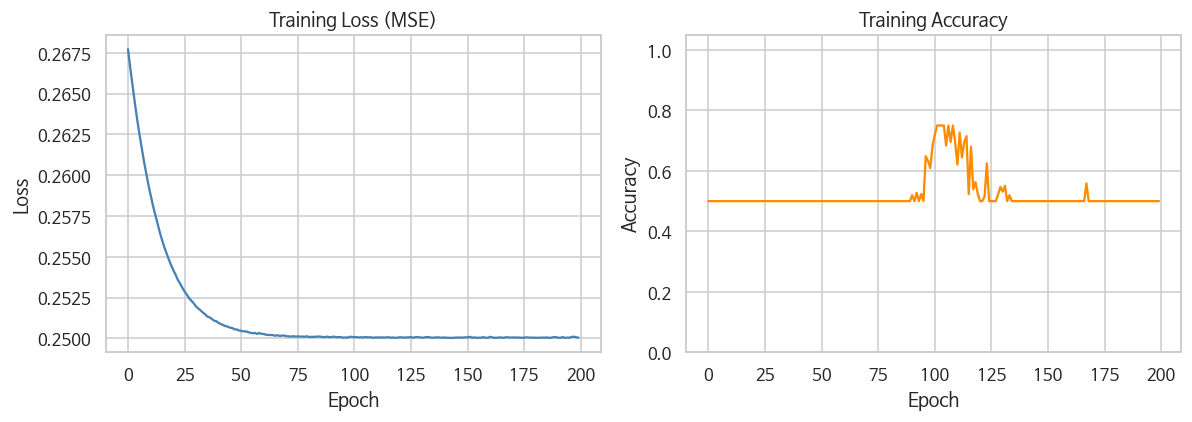

In [ ]:
# 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history['loss'], color='steelblue')
axes[0].set_title('Training Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(history.history['accuracy'], color='darkorange')
axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


## (선택) 더 안정적인 학습 설정

강의 기본 예시는 `MSE + SGD + sigmoid`입니다.  
실무/실험에서는 아래처럼 `Adam + binary_crossentropy + ReLU`를 쓰는 경우도 많습니다.

$$
\mathrm{BCE} = -[y\log\hat{y} + (1-y)\log(1-\hat{y})]
$$


In [ ]:
# 코드

Adam+BCE evaluate: loss=0.0108, acc=1.0000
예측 확률: [0.019 0.993 0.989 0.005]
예측 라벨: [0 1 1 0]


---
# 정리

1. 딥러닝 학습 = **손실 최소화**를 위한 **최적화**
2. 경사하강법: $W \leftarrow W - \alpha \nabla L$
3. 순전파로 예측, 역전파로 기울기 계산
4. TensorFlow 2.x는 Eager Execution이 기본
5. Constant / Sequence / Variable 텐서를 구분해서 사용
6. Keras로 `Sequential → compile → fit → evaluate → predict` 흐름을 익힌다
7. Epoch / Batch / Iteration 관계를 항상 의식한다

$$
1\ \mathrm{Epoch} = \frac{N}{\text{Batch Size}} = \text{Iterations}
$$

## 참고 링크

- TensorFlow 가이드: [https://www.tensorflow.org/guide](https://www.tensorflow.org/guide)
- Keras Sequential: [https://www.tensorflow.org/guide/keras/sequential_model](https://www.tensorflow.org/guide/keras/sequential_model)
- tf.data: [https://www.tensorflow.org/guide/data](https://www.tensorflow.org/guide/data)
- Backpropagation 논문: [https://www.nature.com/articles/323533a0](https://www.nature.com/articles/323533a0)
